## KMeans кластеризация сигналов сцинтилляционного детектора

В данном ноутбуке реализована альтернативная модель кластеризации — метод KMeans. В отличие от Gaussian Mixture Model, использованной в основном решении, KMeans предполагает, что кластеры имеют сферическую форму и равный размер. Это позволяет сравнить два подхода и выбрать наилучший.

Задача: разделить 23479 сигналов на три кластера (гамма-кванты, нейтроны, аномалии).

##Импорты и установка

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!pip install -q gdown
import gdown

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

SEED = 42
np.random.seed(SEED)

print("KMeans кластеризация сигналов сцинтилляционного детектора")

KMeans кластеризация сигналов сцинтилляционного детектора


##Загрузка данных

In [2]:
file_id = "1KESjKG6IIH8PgsykdFxUms7Kkj9Zk_LY"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "signals.txt", quiet=False)

data_full = pd.read_csv('signals.txt', sep=' ', header=None, skipinitialspace=True)
signals = data_full.drop([0, 1, 2, 3, 504], axis=1)
signals.columns = [f'time_{i}' for i in range(500)]

print(f"Загружено {signals.shape[0]} сигналов, каждый длиной {signals.shape[1]} отсчётов")

Downloading...
From: https://drive.google.com/uc?id=1KESjKG6IIH8PgsykdFxUms7Kkj9Zk_LY
To: /content/signals.txt
100%|██████████| 71.3M/71.3M [00:01<00:00, 59.6MB/s]


Загружено 23479 сигналов, каждый длиной 500 отсчётов


##Предобработка

In [3]:
baseline = signals.iloc[:, :60].mean(axis=1).values.reshape(-1, 1)

signals_clean = baseline - signals.values
signals_clean = np.maximum(signals_clean, 0)

signal_max = signals_clean.max(axis=1, keepdims=True)
signals_norm = signals_clean / (signal_max + 1e-8)

print(f"Диапазон нормированных сигналов: [{signals_norm.min():.2f}, {signals_norm.max():.2f}]")

Диапазон нормированных сигналов: [0.00, 1.00]


##Визуализация примеров сигналов

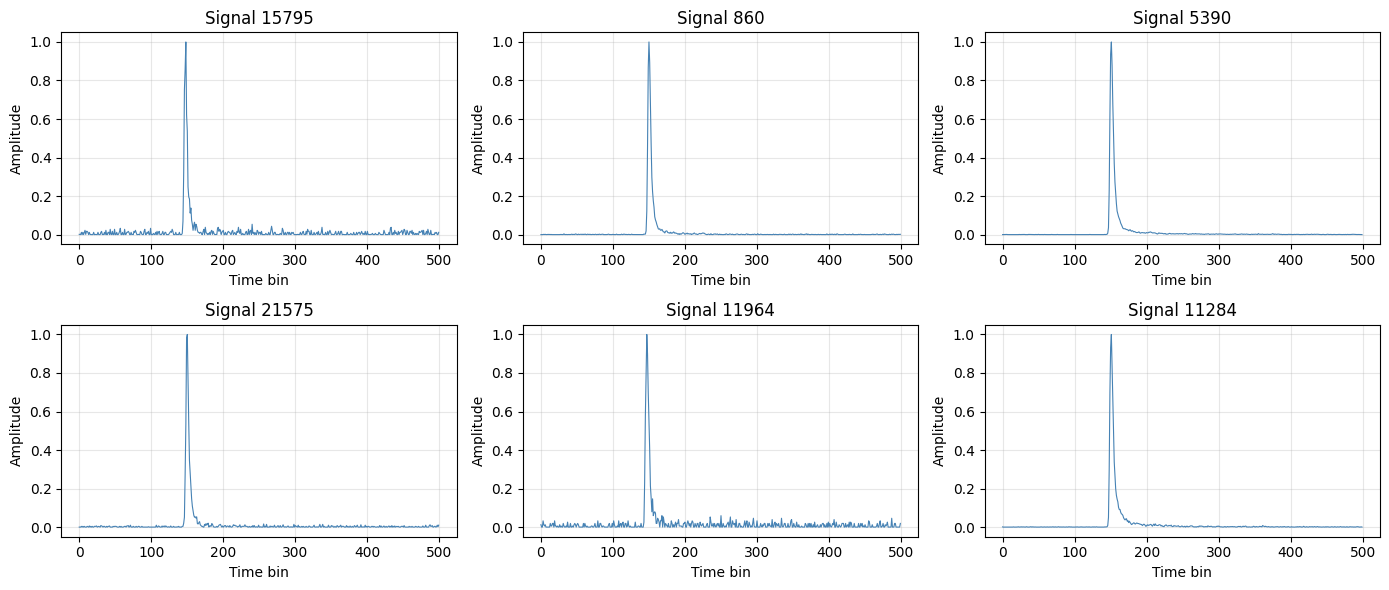

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()

for i in range(6):
    idx = np.random.randint(0, len(signals_norm))
    axes[i].plot(signals_norm[idx], color='steelblue', linewidth=0.8)
    axes[i].set_title(f'Signal {idx}')
    axes[i].set_xlabel('Time bin')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##Извлечение признаков

In [5]:
PEAK = 150
eps = 1e-8

total = signals_norm[:, PEAK-5:PEAK+100].sum(axis=1)
slow = signals_norm[:, PEAK+15:PEAK+100].sum(axis=1)
fast = signals_norm[:, PEAK+5:PEAK+25].sum(axis=1)

r_long = slow / (total + eps)
r_short = fast / (total + eps)
ratio = r_long / (r_short + eps)
asymmetry = (PEAK - np.argmax(signals_norm, axis=1)) / 50
amplitude = signals_clean.max(axis=1)
log_amp = np.log10(amplitude + 1)

X_features = np.column_stack([r_long, r_short, ratio, asymmetry, log_amp])

print(f"Создано {X_features.shape[1]} признаков")

Создано 5 признаков


##Визуализация распределения признаков

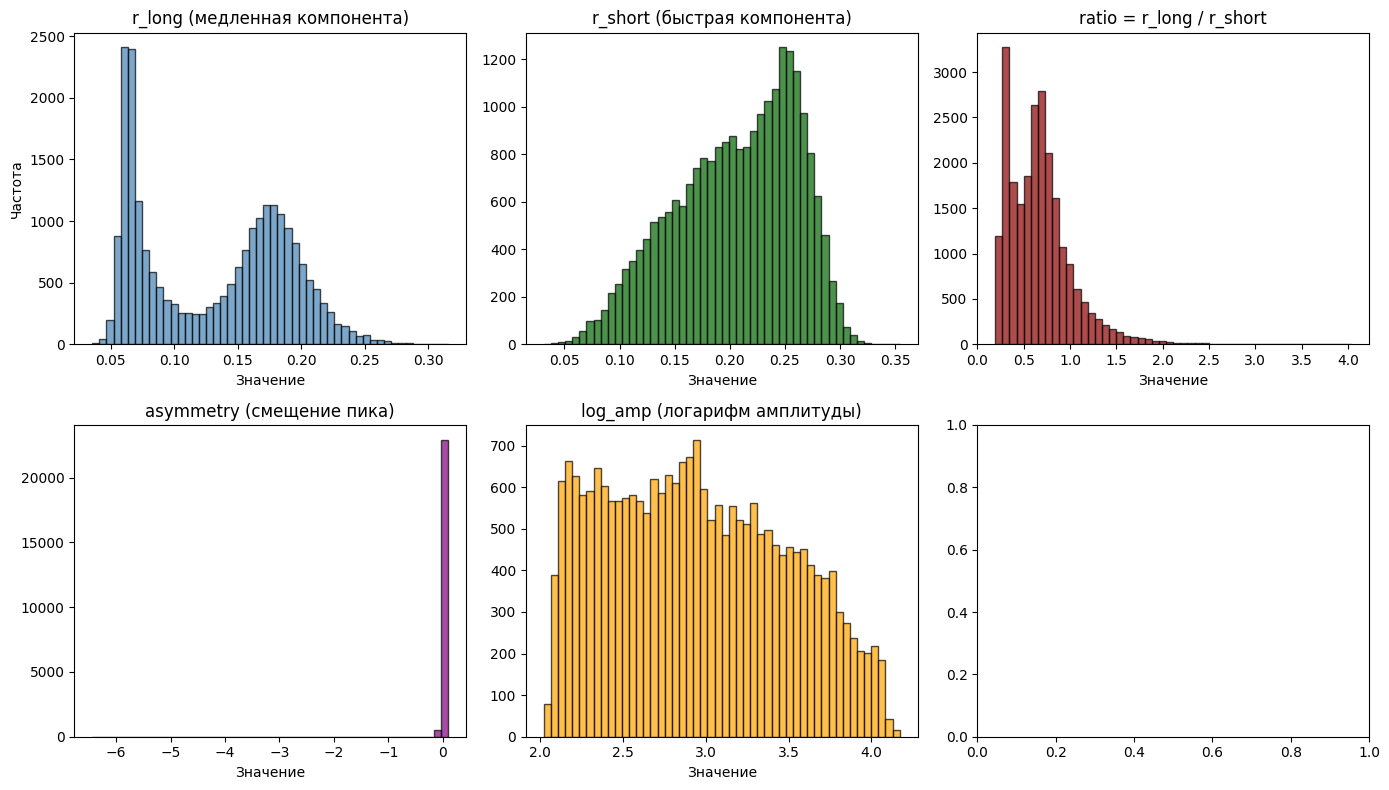

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].hist(r_long, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('r_long (медленная компонента)')
axes[0, 0].set_xlabel('Значение')
axes[0, 0].set_ylabel('Частота')

axes[0, 1].hist(r_short, bins=50, color='darkgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('r_short (быстрая компонента)')
axes[0, 1].set_xlabel('Значение')

axes[0, 2].hist(ratio, bins=50, color='darkred', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('ratio = r_long / r_short')
axes[0, 2].set_xlabel('Значение')

axes[1, 0].hist(asymmetry, bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('asymmetry (смещение пика)')
axes[1, 0].set_xlabel('Значение')

axes[1, 1].hist(log_amp, bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('log_amp (логарифм амплитуды)')
axes[1, 1].set_xlabel('Значение')

plt.tight_layout()
plt.show()

##Визуализация данных в PCA пространстве

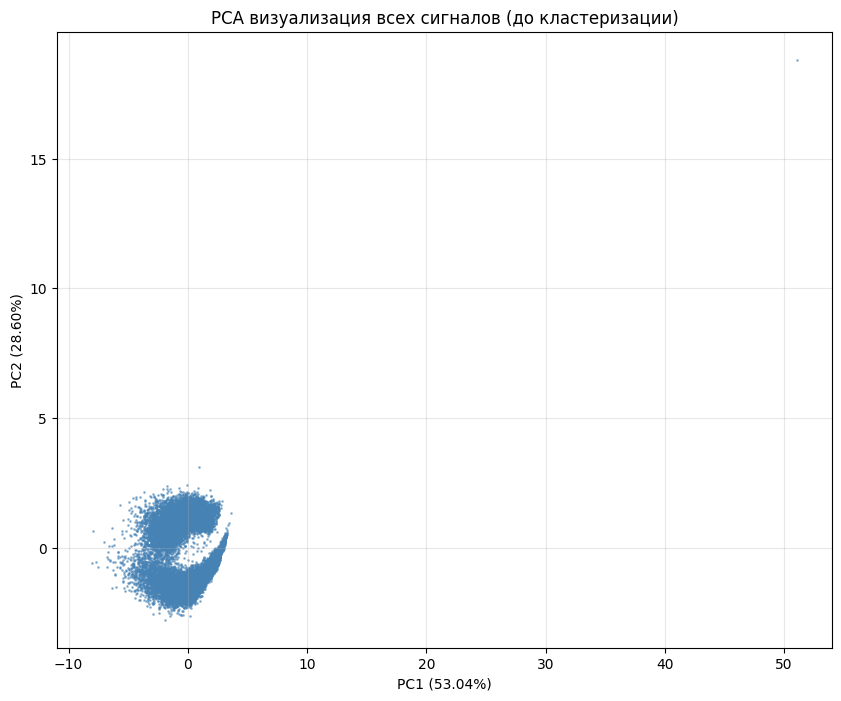

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

pca_full = PCA(n_components=2, random_state=SEED)
X_pca_vis = pca_full.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], s=1, alpha=0.5, c='steelblue')
plt.xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.2%})')
plt.title('PCA визуализация всех сигналов (до кластеризации)')
plt.grid(True, alpha=0.3)
plt.show()

##KMeans кластеризация

In [8]:
pca = PCA(n_components=3, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=20)
raw_labels = kmeans.fit_predict(X_pca)

unique, counts = np.unique(raw_labels, return_counts=True)
order = np.argsort(counts)[::-1]
mapping = {old: new for new, old in enumerate(order)}
final_labels = np.array([mapping[l] for l in raw_labels])

silhouette = silhouette_score(X_pca, final_labels)
print(f"Silhouette Score: {silhouette:.4f}")

print("\nРаспределение по кластерам:")
for i in range(3):
    cnt = np.sum(final_labels == i)
    print(f"  Кластер {i}: {cnt} сигналов ({cnt/len(final_labels)*100:.1f}%)")

Silhouette Score: 0.4633

Распределение по кластерам:
  Кластер 0: 8895 сигналов (37.9%)
  Кластер 1: 8555 сигналов (36.4%)
  Кластер 2: 6029 сигналов (25.7%)


##Визуализация результатов кластеризации

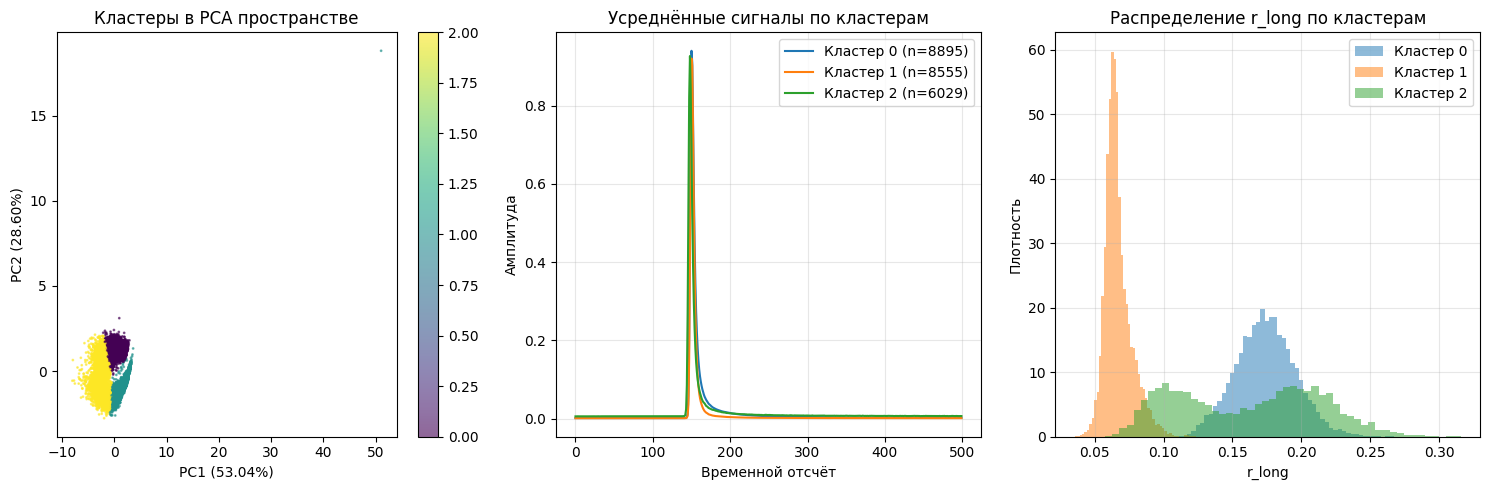

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# PCA пространство с цветами кластеров
scatter = axes[0].scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=final_labels, cmap='viridis', s=1, alpha=0.6)
axes[0].set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.2%})')
axes[0].set_title('Кластеры в PCA пространстве')
plt.colorbar(scatter, ax=axes[0])

# Средние сигналы по кластерам
for i in range(3):
    cluster_signals = signals_norm[final_labels == i]
    if len(cluster_signals) > 0:
        mean_signal = np.mean(cluster_signals, axis=0)
        axes[1].plot(mean_signal, label=f'Кластер {i} (n={len(cluster_signals)})', linewidth=1.5)
axes[1].set_title('Усреднённые сигналы по кластерам')
axes[1].set_xlabel('Временной отсчёт')
axes[1].set_ylabel('Амплитуда')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Распределение r_long по кластерам
for i in range(3):
    r_long_cluster = r_long[final_labels == i]
    axes[2].hist(r_long_cluster, bins=50, alpha=0.5, label=f'Кластер {i}', density=True)
axes[2].set_title('Распределение r_long по кластерам')
axes[2].set_xlabel('r_long')
axes[2].set_ylabel('Плотность')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##Cабмишн

In [10]:
submission = pd.DataFrame({'index': np.arange(len(final_labels)), 'cluster': final_labels})
submission.to_csv('submission_kmeans.csv', index=False)
print("Файл submission_kmeans.csv сохранён")

from google.colab import files
files.download('submission_kmeans.csv')

Файл submission_kmeans.csv сохранён


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Выводы по KMeans модели

**Параметры модели:**
- n_clusters = 3 (в соответствии с задачей)
- n_init = 20 (количество запусков с разными инициализациями)
- random_state = 42 (фиксация для воспроизводимости)
- max_iter = 300 (по умолчанию, сходимость достигнута)

**Признаки (5 шт.):**
- r_long — отношение интеграла хвоста к полному интегралу (медленная компонента)
- r_short — отношение интеграла раннего хвоста к полному интегралу (быстрая компонента)
- ratio = r_long / r_short — усиление различий между типами частиц
- asymmetry — смещение пика относительно 150-го отсчёта (уникальный признак)
- log_amp — логарифм максимальной амплитуды (энергетическая характеристика)

**Предобработка:**
- Базовая линия: среднее по первым 60 отсчётам
- Обнуление отрицательных значений (шумовых флуктуаций)
- Нормировка на максимум (приведение к диапазону [0, 1])

**Результаты кластеризации:**
- Silhouette Score: 0.4633
- Распределение кластеров:
  - Кластер 0: 8895 сигналов (37.9%)
  - Кластер 1: 8555 сигналов (36.4%)
  - Кластер 2: 6029 сигналов (25.7%)
- Результат на Kaggle: 0.66851

**Сравнение с GMM (основное решение):**
| Параметр | KMeans | GMM |
|----------|--------|-----|
| Silhouette Score | 0.4633 | 0.4009* |
| Kaggle Score | 0.66851 | 0.84487 |
| Форма кластеров | Сферические | Произвольные |
| Скорость работы | Быстро | Средне |

*GMM показал более низкий Silhouette, но более высокий Kaggle Score, что говорит о том, что внутренние метрики не всегда отражают реальное качество для конкретной задачи.

**Почему GMM оказался лучше:**
- KMeans предполагает, что кластеры имеют сферическую форму и примерно равный размер
- Реальные сигналы детектора образуют кластеры разной формы (вытянутые, разной плотности)
- GMM позволяет моделировать такие кластеры за счёт ковариационных матриц

**Вывод:** для данной задачи Gaussian Mixture Model является более предпочтительным методом, так как он лучше учитывает реальную структуру данных. KMeans может использоваться как быстрый baseline, но для достижения максимального качества (0.84) необходима GMM с правильно подобранными признаками и параметрами предобработки.